E:\develop\anaconda3\envs\d2l_tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


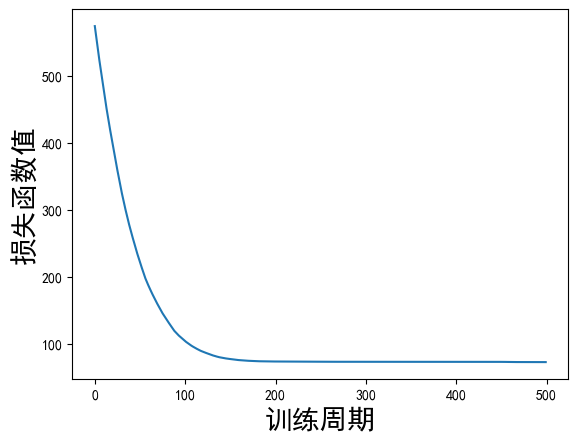

In [10]:
'''
    使用神经网络层实现上面的案例
'''
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

#产生随机数
n = 100
x = np.linspace(0,100,n)
y = np.linspace(0,100,n)

#加入噪音
X = x + np.random.uniform(-10,10,n)
Y = y + np.random.uniform(-10,10,n)

#建立模型(仅使用一个神经网络层--->完全连接层)
##定义神经层参数:  input_shape 输入神经元个数 units:输出神经元个数
layer1 = tf.keras.layers.Dense(units=1,input_shape=[1])

##将神经层加入神经网络
model = tf.keras.Sequential([layer1])

#定义模型的损失函数和优化器
model.compile(loss='mean_squared_error',optimizer=tf.keras.optimizers.Adam())

#模型训练
history = model.fit(X,Y,epochs=500,verbose=False)

#可视化结果
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.xlabel('训练周期',fontsize=20)
plt.ylabel('损失函数值',fontsize=20)
plt.plot(history.history['loss'],label='训练损失函数值')

第0 轮的损失函数值为3379.5693359375
第1 轮的损失函数值为430.5573425292969
第2 轮的损失函数值为114.07495880126953
第3 轮的损失函数值为80.11055755615234
第4 轮的损失函数值为76.4654312133789
第5 轮的损失函数值为76.0741195678711
第6 轮的损失函数值为76.03199005126953
第7 轮的损失函数值为76.02735137939453
第8 轮的损失函数值为76.02674102783203
第9 轮的损失函数值为76.02655029296875
第10 轮的损失函数值为76.02639770507812
第11 轮的损失函数值为76.0262680053711
第12 轮的损失函数值为76.02613067626953
第13 轮的损失函数值为76.0259780883789
第14 轮的损失函数值为76.0258560180664
第15 轮的损失函数值为76.02571105957031
第16 轮的损失函数值为76.02557373046875
第17 轮的损失函数值为76.02543640136719
第18 轮的损失函数值为76.02529907226562
第19 轮的损失函数值为76.02515411376953
第20 轮的损失函数值为76.02503204345703
第21 轮的损失函数值为76.02489471435547
第22 轮的损失函数值为76.02474975585938
第23 轮的损失函数值为76.02460479736328
第24 轮的损失函数值为76.02446746826172
第25 轮的损失函数值为76.02432250976562
第26 轮的损失函数值为76.0241928100586
第27 轮的损失函数值为76.02405548095703
第28 轮的损失函数值为76.02391052246094
第29 轮的损失函数值为76.02378845214844
第30 轮的损失函数值为76.02364349365234
第31 轮的损失函数值为76.02350616455078
第32 轮的损失函数值为76.02336883544922
第33 轮的损失函数值为76.023231506347

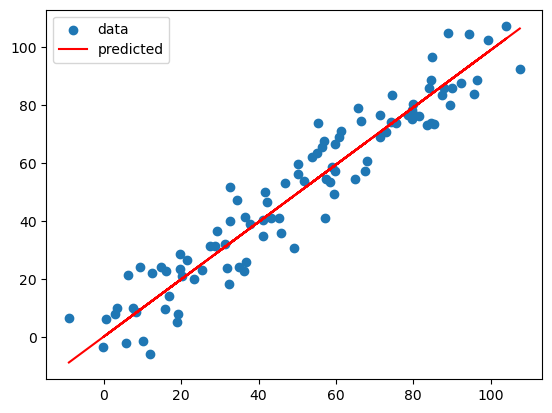

In [25]:
'''
    手动实现
'''
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

w = tf.Variable(0.0)
b = tf.Variable(0.0)
#定义损失函数
def loss(y,y_pred):
    return tf.reduce_mean(tf.square(y-y_pred))

#定义预测函数
def predict(X):
    return w * X + b

#定义训练函数
def train(X,y,epochs=500,lr=0.0001):
    curr_loss = 0
    for epoch in range(epochs):
        with tf.GradientTape() as t:
            curr_loss = loss(y,predict(X))
        dw,db = t.gradient(curr_loss,[w,b])
        #更新权重
        w.assign_sub(lr * dw)
        b.assign_sub(lr * db)
        print(f'第{epoch} 轮的损失函数值为{curr_loss.numpy()}')


#生成随机样本数据
n = 100
x = np.linspace(0,100,n)
y = np.linspace(0,100,n)

#加入噪音
X = x + np.random.uniform(-10,10,n)
y = y + np.random.uniform(-10,10,n)

train(X,y)
print(f'w的权重是:{w.numpy()},b的权重是:{b.numpy()}')
#绘制结果
plt.scatter(X,y,label="data")
plt.plot(X,predict(X),"r-",label="predicted")

plt.legend()
